# 带正则化的多元线性回归 — 加州房价数据集
> 手写 Ridge 回归（L2 正则化），对比不同 λ 下模型表现

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False


In [2]:
# 加载数据
housing = fetch_openml(name="california_housing", version=1, parser="auto")

numeric_cols = ["longitude", "latitude", "housing_median_age", "total_rooms",
                "total_bedrooms", "population", "households", "median_income"]
X = housing.data[numeric_cols].values.astype(np.float64)
y = housing.target.values.astype(np.float64)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
X = imputer.fit_transform(X)

print(f"数据量: {X.shape[0]} 条  |  特征数: {X.shape[1]} 个")


数据量: 20640 条  |  特征数: 8 个


In [3]:
# 切分 & 标准化
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"训练集: {X_train.shape}  |  测试集: {X_test.shape}")

训练集: (16512, 8)  |  测试集: (4128, 8)


---
## 手写 Ridge 回归（L2 正则化）

**公式：$\theta = (X^T X + \lambda I)^{-1} X^T y$**

多出来的 $\lambda I$ 做了两件事：
- 收缩系数 → 防止过拟合
- 保证 $X^TX$ 可逆 → 数值更稳定

λ 越大 → 系数越接近 0；λ=0 → 退化为普通线性回归

In [4]:
class MyRidgeRegression:
    """手写 Ridge 回归 — L2 正则化"""

    def __init__(self, alpha=1.0):
        self.alpha = alpha          # λ（正则化强度）
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])

        # 构造单位阵，但截距项不惩罚（对角第一个元素=0）
        I = np.eye(X_b.shape[1])  #和X_b列数一样大单位矩阵
        I[0, 0] = 0

        # Ridge 正规方程: θ = (XᵀX + λI)⁻¹ Xᵀy
        theta = np.linalg.inv(X_b.T @ X_b + self.alpha * I) @ X_b.T @ y

        self.intercept_ = theta[0]
        self.coef_ = theta[1:]
        return self

    def predict(self, X):
        return X @ self.coef_ + self.intercept_

---
## 不同 λ 下训练 & 对比

In [5]:
# 先跑一个普通线性回归作为基线
ols = MyRidgeRegression(alpha=0)
ols.fit(X_train, y_train)
ols_r2 = 1 - np.sum((y_test - ols.predict(X_test))**2) / np.sum((y_test - y_test.mean())**2)
print(f"普通线性回归（λ=0）测试集 R²: {ols_r2:.4f}")
print(f"系数: {ols.coef_.round(2)}")

普通线性回归（λ=0）测试集 R²: 0.6139
系数: [-85503.22 -90698.85  14905.91 -17805.42  48712.34 -43766.49  17654.5
  77194.7 ]


In [6]:
# 测试一系列 λ 值   越大表示惩罚越重
alphas = [0.01, 0.1, 0.5, 1, 5, 10, 50, 100, 500, 1000]

results = []
all_coefs = []

for a in alphas:
    ridge = MyRidgeRegression(alpha=a)
    ridge.fit(X_train, y_train)

    y_pred = ridge.predict(X_test)
    ss_res = np.sum((y_test - y_pred)**2)
    ss_tot = np.sum((y_test - y_test.mean())**2)
    r2_test = 1 - ss_res / ss_tot
    rmse_test = np.sqrt(np.mean((y_test - y_pred)**2))

    results.append({'alpha': a, 'r2': r2_test, 'rmse': rmse_test})
    all_coefs.append(ridge.coef_)

    print(f"λ={a:>5}  |  R²={r2_test:.4f}  |  RMSE={rmse_test:.2f}")

all_coefs = np.array(all_coefs)

λ= 0.01  |  R²=0.6139  |  RMSE=71133.14
λ=  0.1  |  R²=0.6139  |  RMSE=71132.81
λ=  0.5  |  R²=0.6139  |  RMSE=71131.38
λ=    1  |  R²=0.6139  |  RMSE=71129.61
λ=    5  |  R²=0.6141  |  RMSE=71115.83
λ=   10  |  R²=0.6142  |  RMSE=71099.64
λ=   50  |  R²=0.6153  |  RMSE=71004.90
λ=  100  |  R²=0.6159  |  RMSE=70949.61
λ=  500  |  R²=0.6108  |  RMSE=71412.12
λ= 1000  |  R²=0.5991  |  RMSE=72477.52


---
## 可视化

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_30148\1314440648.py:49: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' 

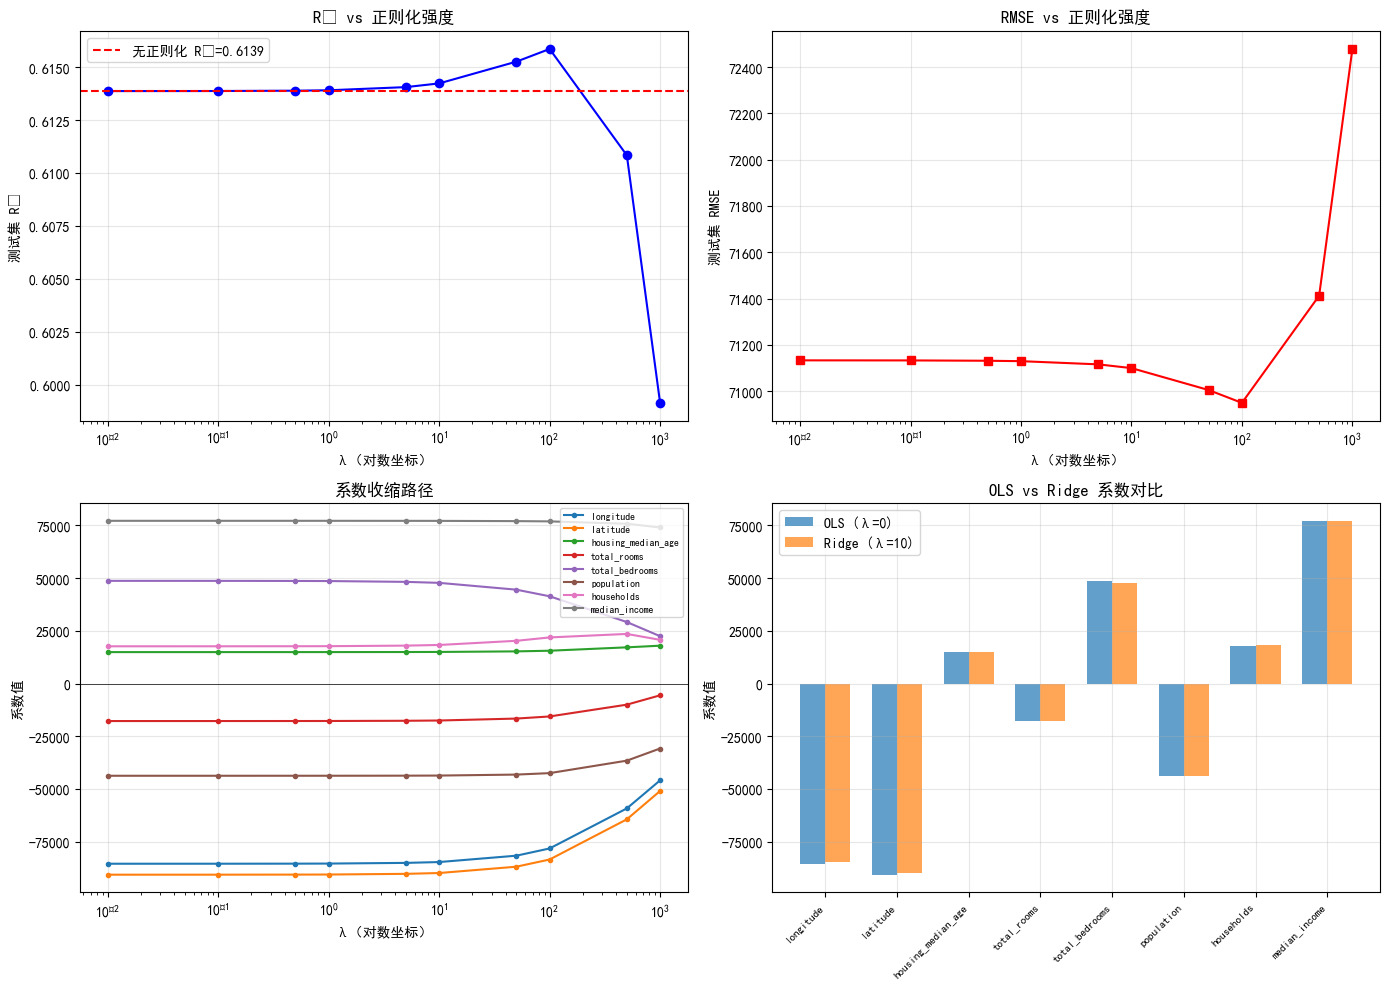

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- 图1: R² 随 λ 变化 ----
ax = axes[0, 0]
r2_vals = [r['r2'] for r in results]
ax.semilogx(alphas, r2_vals, 'b-o', markersize=6)
ax.axhline(ols_r2, color='red', linestyle='--', label=f'无正则化 R²={ols_r2:.4f}')
ax.set_xlabel('λ（对数坐标）')
ax.set_ylabel('测试集 R²')
ax.set_title('R² vs 正则化强度')
ax.legend()
ax.grid(True, alpha=0.3)

# ---- 图2: RMSE 随 λ 变化 ----
ax = axes[0, 1]
rmse_vals = [r['rmse'] for r in results]
ax.semilogx(alphas, rmse_vals, 'r-s', markersize=6)
ax.set_xlabel('λ（对数坐标）')
ax.set_ylabel('测试集 RMSE')
ax.set_title('RMSE vs 正则化强度')
ax.grid(True, alpha=0.3)

# ---- 图3: 系数收缩路径 ----
ax = axes[1, 0]
for i, name in enumerate(numeric_cols):
    ax.semilogx(alphas, all_coefs[:, i], '-o', markersize=3, label=name)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('λ（对数坐标）')
ax.set_ylabel('系数值')
ax.set_title('系数收缩路径')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

# ---- 图4: OLS vs Ridge 系数对比（λ=10）----
ax = axes[1, 1]
best = MyRidgeRegression(alpha=10)
best.fit(X_train, y_train)
x = np.arange(len(numeric_cols))
w = 0.35
ax.bar(x - w/2, ols.coef_, w, label='OLS (λ=0)', alpha=0.7)
ax.bar(x + w/2, best.coef_, w, label='Ridge (λ=10)', alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('系数值')
ax.set_title('OLS vs Ridge 系数对比')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 总结

| λ | 效果 |
|------|------|
| 0 | 退化为普通线性回归 |
| 小（0.1~1） | 轻微收缩，防止过拟合 |
| 中（5~50） | 明显压缩大系数 |
| 大（>100） | 系数趋近于 0，模型退化为只预测均值 |

Ridge 不会像 Lasso 那样将系数压到恰好=0，它只是让所有系数整体收缩。